# Task 6 — Music Genre Classification

**Objectif :** classifier des morceaux par genre musical à partir de features audio déjà extraites (MFCC, chroma, spectral...).

**Dataset :** GTZAN (Kaggle) — 9990 segments de 3 secondes, 10 genres, 58 features tabulaires.

In [1]:
# setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Chargement des données

In [2]:
# fichier en segments de 3s -> plus de lignes que la version 30s, mieux pour entraîner
df = pd.read_csv("../data/features_3_sec.csv")
print(df.shape)
df.head()

(9990, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [3]:
# check rapide, équilibre des genres
print(df.isnull().sum().sum())
df["label"].value_counts()

0


label
blues        1000
jazz         1000
pop          1000
reggae       1000
metal        1000
disco         999
classical     998
hiphop        998
rock          998
country       997
Name: count, dtype: int64

## 2. Distribution des genres

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_25520\3038560359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="label", data=df, order=df["label"].value_counts().index, palette="flare", ax=ax)


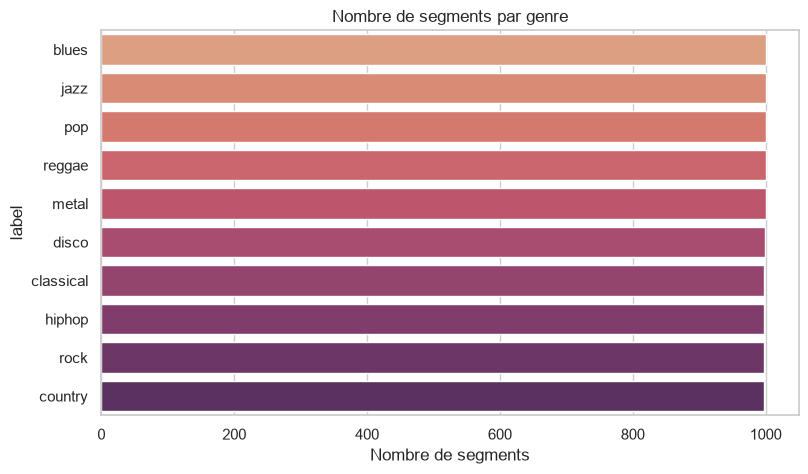

In [4]:
fig, ax = plt.subplots()
sns.countplot(y="label", data=df, order=df["label"].value_counts().index, palette="flare", ax=ax)
ax.set_title("Nombre de segments par genre")
ax.set_xlabel("Nombre de segments")
plt.savefig("../outputs/01_genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Préparation des données

In [5]:
# on enlève filename (identifiant, pas une feature) et length (constant, sans valeur)
X = df.drop(columns=["filename", "length", "label"])
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(X.shape)
X.head(2)

(9990, 57)


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,1.080790e+06,...,-2.853603,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767
1,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,6.722448e+05,...,4.074709,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081


In [6]:
# scaling indispensable : les features audio ont des échelles très différentes (variance vs moyenne, mfcc vs chroma...)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(X_train.shape, X_test.shape)

(7992, 57) (1998, 57)


## 4. Modèle — Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.87      0.86      0.87       200
   classical       0.90      0.95      0.93       199
     country       0.80      0.83      0.82       199
       disco       0.85      0.84      0.85       200
      hiphop       0.92      0.90      0.91       200
        jazz       0.85      0.90      0.87       200
       metal       0.87      0.97      0.92       200
         pop       0.95      0.81      0.88       200
      reggae       0.82      0.88      0.85       200
        rock       0.89      0.76      0.82       200

    accuracy                           0.87      1998
   macro avg       0.87      0.87      0.87      1998
weighted avg       0.87      0.87      0.87      1998



## 5. Matrice de confusion

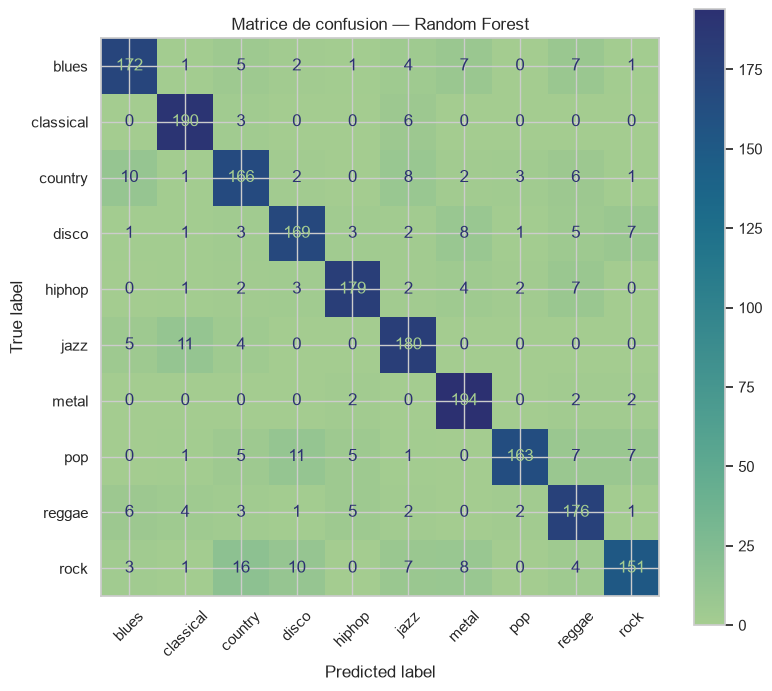

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="crest", colorbar=True, xticks_rotation=45)
ax.set_title("Matrice de confusion — Random Forest")
plt.savefig("../outputs/02_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature importance

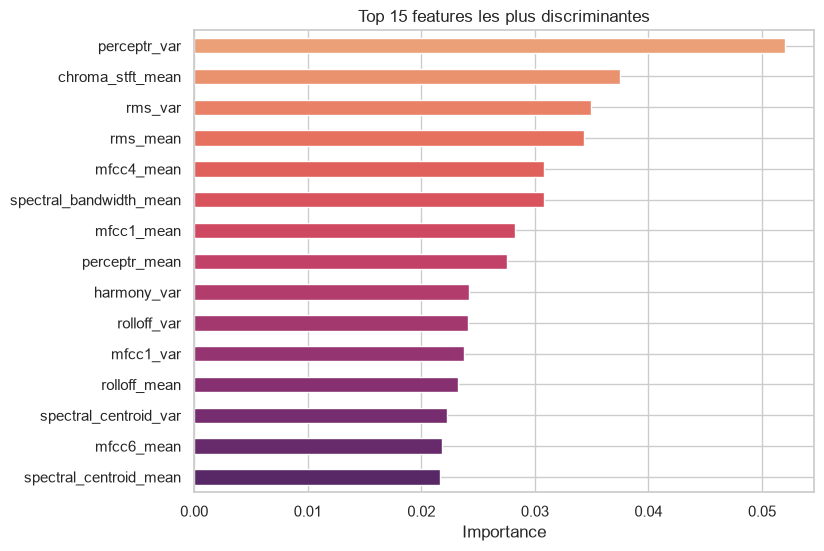

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color=sns.color_palette("flare", len(importances)))
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 features les plus discriminantes")
plt.savefig("../outputs/03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Comparaison avec SVM

In [10]:
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

=== SVM ===
              precision    recall  f1-score   support

       blues       0.83      0.85      0.84       200
   classical       0.86      0.96      0.91       199
     country       0.83      0.81      0.82       199
       disco       0.77      0.81      0.79       200
      hiphop       0.90      0.81      0.86       200
        jazz       0.85      0.88      0.87       200
       metal       0.92      0.92      0.92       200
         pop       0.90      0.82      0.86       200
      reggae       0.82      0.86      0.84       200
        rock       0.77      0.73      0.75       200

    accuracy                           0.85      1998
   macro avg       0.85      0.85      0.84      1998
weighted avg       0.85      0.85      0.84      1998



In [11]:
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    "Modèle": ["Random Forest", "SVM (RBF)"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_svm)],
    "F1 (macro)": [f1_score(y_test, y_pred_rf, average="macro"), f1_score(y_test, y_pred_svm, average="macro")],
})
comparison

,Modèle,Accuracy,F1 (macro)
0,Random Forest,0.870871,0.870285
1,SVM (RBF),0.845345,0.844934


## 8. Comparaison tabulaire vs image (spectrogrammes)

Le dataset GTZAN fournit aussi les fichiers audio bruts + des spectrogrammes déjà générés en image (dossier `images_original/`). Une approche CNN sur ces images est possible en complément — à faire dans un notebook séparé (`06b_cnn_spectrograms.ipynb`) si tu veux comparer les deux approches, car l'entraînement d'un CNN est nettement plus long qu'un Random Forest sur features tabulaires.

**Prochaine étape possible :** tester le fichier `features_30_sec.csv` (moins de lignes mais moins de bruit, chaque ligne résume un morceau entier plutôt qu'un segment de 3s) pour voir si la performance change.